> Mit einem klaren Plan zum Ziel

___
In dieser Kurseinheit beschäftigen wir uns mit der Datenmodellierung für das spaltenfamilienbasiertes Datenbanksystem (Column-Family Database) Cassandra.

**_Bitte beachten:_**

- In Raw-Zellen erwarten wir Antworten im Freitext-Format. In Code-Zellen soll Code eingefügt werden (bei Bedarf mit Kommentaren). Weitere Formate werden mit Markdown bearbeitet.
- Fragestellungen sind teilweise bewusst etwas offener formuliert, weil Sie auch im Arbeitsleben nur selten mit ganz spezifischen Anweisungen rechnen können. Es gibt häufig mehrere mögliche Lösungen, dies wird in der Korrektur berücksichtigt.

In diesem Kurs setzen wir unsere Arbeit mit den Datensätzen von Refill-Deutschland und Mundraub fort.
Refill-Deutschland und Mundraub sind Plattformen, die die Standorte von Früchten, Pflanzen und Zapfstellen (Wasser) in Deutschland erfassen. Beide Datensätze stammen aus <a href="https://www.govdata.de/">GovData</a> und beinhalten geographische Punkte, an denen es freien Zugang zu Wasser und Lebensmittel gibt. Angesichts der positiven Resonanz, die die Projekte Mundraub- und die Refillstationen- in den sozialen Netzwerken erfahren haben, ist es unser Ziel, beide strategisch zu fördern. Dazu sollen die Informationen beider Projekte auf einer zentralen Plattform zusammengeführt werden.

Zu Beginn werden zwei Designs vorgestellt. Die Schemaerstellung und der Datenimport in Cassandra können mithilfe von Bash-Skripten durchgeführt werden. Für die Datenabfragen wird der bereits installierte <a href="https://docs.datastax.com/en/developer/python-driver/3.25/">Cassandra-Treiber</a> empfohlen.

Im Gegensatz zu MongoDB hat Cassandra keine eingebaute Geo-Indexierung. Daher kommt zur Lokalisierung Geohash zum Einsatz, diese sind alphanumerische Zeichenketten und repräsentieren Quadrate auf der Erdoberfläche. Diese Kodierung erleichtert das Gruppieren, Vergleichen und effiziente Durchsuchen räumlicher Daten. Zur Umwandlung von geografischen Koordinaten (Breiten- und Längengrad) in Geohashes wird die Bibliothek <a href="https://pypi.org/project/libgeohash/">`libgeohash`</a> verwendet.

Zur Distanzberechnung wird die Haversine-Formel verwendet. Zur Anwendung dieser Formel nutzen wir die Bibliothek <a href="https://pypi.org/project/haversine/">`haversine`</a>, mit der sich die Entfernung zwischen zwei Punkten auf der Erdoberfläche in Metern ermitteln lässt.

Für jedes Modell sollen die Latenzzeiten pro Leseanfrage mindestens dreimal gemessen. Anschließend wird die Gesamtlatenz für jedes Design ausgegeben. Wir empfehlen hierfür die Verwendung von  <a href="https://docs.python.org/3/library/timeit.html">`timeit`</a> zur Messung der Ausführungszeit und <a href="https://matplotlib.org/stable/index.html">`matplotlib`</a> zur grafischen Darstellung der Ergebnisse.

Sie können jedoch frei entscheiden, welche Tools Sie nutzen möchten. Wenn Sie sich für andere Tools entscheiden, denken Sie bitte daran, diese entsprechend zu installieren.
 
Die Verwendung externer Quellen und das Einfügen von Anmerkungen am Ende des Protokolls ist weiterhin erlaubt! :)

___

Um die zuvor erwähnten Bibliotheken zu importieren und zu installieren, führen Sie bitte die folgenden Zellen aus:

In [ ]:
!pip install libgeohash haversine

In [ ]:
# Imports
import os

import libgeohash as geohash
import math
from haversine import haversine, Unit

import timeit
import numpy as np
import matplotlib.pyplot as plt

import cassandra
from cassandra.cluster import Cluster
from cassandra.query import BatchStatement
from pprint import pprint

Da wir im weiteren Verlauf Zugriff auf die Daten benötigen, stellen wir zunächst die entsprechenden Variablen ein.

In [ ]:
# Absolute path :: to the folder cotaining the git repo
host_repo_path = "/CHANGE/ME/data-engineering-infrastructure.git/"

# elative path :: to the folder containing the Dataset-files (INSIDE OF THE WORKSPACE FOLDER!)
workspace_data_path = "CHANGE/ME"
os.environ['HOST_DATA_PATH'] = os.path.join(host_repo_path, "workspace", workspace_data_path)
os.environ['DATA_PATH'] = os.path.join("/home/pyspark-client/workspace", workspace_data_path)

# uncomment to verify the content of the DATA_PATH
#!ls ${DATA_PATH}

# Schema Design

Zunächst beschäftigen wir uns mit der <a href="https://cassandra.apache.org/doc/5.0/cassandra/developing/data-modeling/index.html">Modellierung</a> in dem spaltenfamilienbasierten Datenbanksystem Apache Cassandra.
Ähnlich wie bei MongoDB richtet sich auch in Cassandra die Datenmodellierung nach den Anforderungen der jeweiligen Anwendung.
Cassandra unterstützt keine Joins. Falls notwendig, müssen zusätzliche denormalisierte Tabellen erstellt werden, um komplexe Ergebnisse abzubilden, andernfalls erfolgt die Zusammenführung der Daten auf der Client-Seite. Eine Einführung in das Data Modeling mit Cassandra finden Sie unter:
<a href="https://www.datastax.com/blog/basic-rules-cassandra-data-modeling">Basic Rules of Apache Cassandra</a>.

Das geplante System soll die folgenden Abfragen unterstützen:

**Read-Abfragen:**

- **Q1**. Gesamtanzahl aller vorhandenen Standorte anzeigen.
    - Auszugebende Attribute: *count_locations*

- **Q2**. Gesamtanzahl aller Mundraub-Plätze.
    - Auszugebende Attribute: *total_mundraub*

- **Q3**. Gesamtanzahl aller Refill-Stationen.
    - Auszugebende Attribute: *total_refill*

- **Q4**. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.
    - Gegebene Attribute: *Location.geom.longitude*, *Location.geom.latitude*, *maxDistance*
    - Auszugebende Attribute: *Station.fid*, Distance, *Refill.station_name*, *Mundraub.kind*, *Station.typ*
  
- **Q5**. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.
    - Gegebene Attribute: *Station.fid*
    - Auszugebende Attribute: *Station.fid*, *Station.rating*, *Refill.station_name*, *Refill.opening_hours*, *Refill.description*, *Location.city*, *Location.geom*, *Location.id*, *Location.plz*, *Location.street*, *Feedback.content*, *Feedback.created_at*, *Feedback.id*, *Feedback.rating*
    
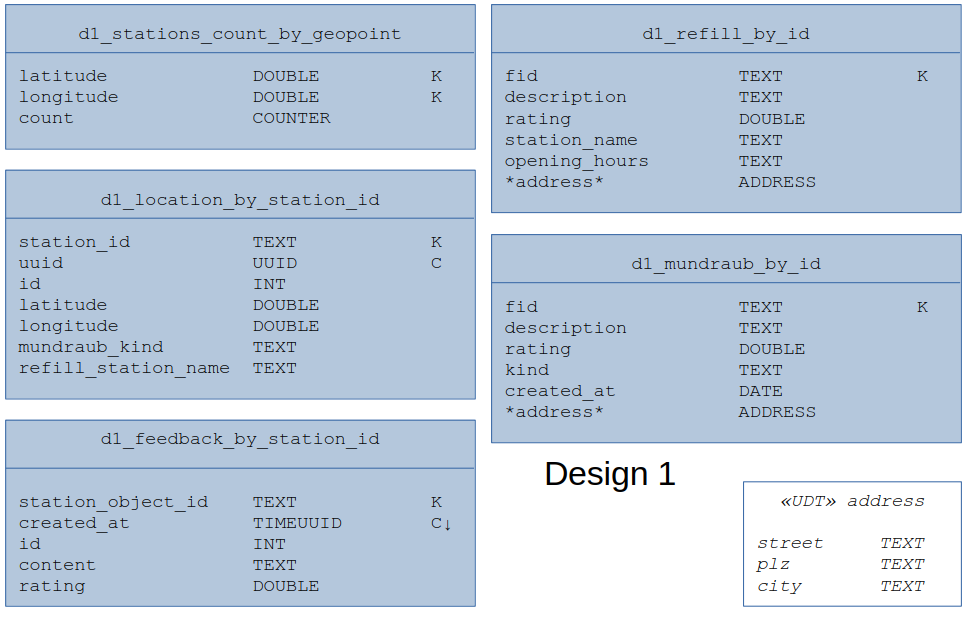


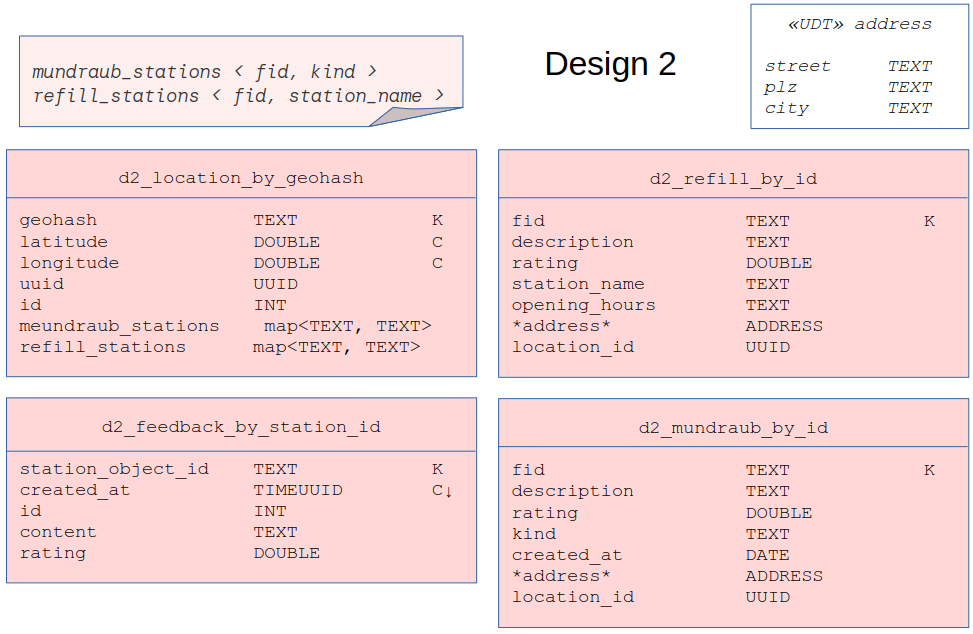

*Hinweis: `geohash`, in Design 2, ist eine kurze alphanumerische Zeichenkette, die einen bestimmten Quadrat auf der Erdoberfläche darstellt. Er wird aus einem geografischen Punkt, also einem Breiten- und Längengrad, berechnet und fasst diese Information in einem kompakten Format zusammen.*

## Let's check the cake
Die empfohlene Größe für Partitionen in Cassandra beträgt 100.000 Cells. Berechnen Sie die Größe der aktuell größten Partition (siehe [https://cassandra.apache.org/doc/latest/cassandra/data_modeling/data_modeling_refining.html](https://cassandra.apache.org/doc/latest/cassandra/data_modeling/data_modeling_refining.html)).

Berechnung der *partition size*:

$$ N_v = N_r(N_c - N_{pk} − N_s) + N_s $$

$$ N_v = \text{Number of values (or cells)} $$
$$ N_s = \text{Number of static columns} $$
$$ N_r = \text{Estimated number of rows per partition} $$
$$ N_c = \text{Number of columns} $$
$$ N_{pk} = \text{Number of primary key columns} $$

| Tabelle                       | Nc | Npk | Ns | Nr    | Nv     |
|------------------------------:|:--:|:---:|:--:|------:|-------:|
|_d1_stations_count_by_geopoint_| 3  | 2   | -  | 1476  |  1476  |
|_d1_location_by_station_id_    | 7  | 1   | -  | 1546  |  9276  |
|_d1_mundraub_by_id_            | 6  | 1   | -  | 1365  |  6825  |
|_d1_refill_by_id_              | 6  | 1   | -  |  181  |   905  |
|_d1_feedback_by_station_id_    | 5  | 1   | -  | 6000  | 24000  |
|_d2_location_by_geohash_       | 7  | 1   | -  | 1476  |  8856  |
|_d2_mundraub_by_id_            | 7  | 1   | -  | 1365  |  8190  |
|_d2_refill_by_id_              | 7  | 1   | -  |  181  |  1086  |
|_d2_feedback_by_station_id_    | 5  | 1   | -  | 6000  | 24000  |

## Sharing is caring, especially cake.
Welche Möglichkeiten bzw. Modellierungsstrategien bezüglich des Schema-Designs gibt es, um zu große Partitionen zu vermeiden?

## Letzte Chance – rote(s) oder blaue(s) (Design)?
Welches Design bevorzugen Sie? Bitte geben Sie kurz Ihre Begründung an.

# Daten Import
Im Folgenden beschäftigen wir uns mit dem Import von Daten. Dazu verwenden wir das zuvor ausgewählte Design.

Führen Sie die folgende Zelle aus, um den Docker-Container mit der Cassandra-Datenbank namens `cassandra_container_1` zu starten. Dieser befindet sich im selben Docker-Netzwerk, wie die anderen Container. Das verwendete Docker-Image enthält bereits den <a href="https://docs.datastax.com/en/dsbulk/overview/dsbulk-about.html">DataStax Bulk</a> Loader für einen effizienten Import von JSON- oder CSV-Dateien.

In [ ]:
!sudo docker run -d --rm \
--name cassandra_container_1 \
--hostname cassandra_container_1 \
-v "${HOST_DATA_PATH}:/mnt/data:ro" \
--network dbis-hadoop-cluster-network \
-p 127.0.0.1:9042:9042 \
registry.dbis-pro1.fernuni-hagen.de/pub-access/data-engineering-infrastructure/cassandra:4.1.1-dsbulk-1.10-c1

Vergewissern Sie sich, dass der Docker-Container läuft:

In [ ]:
%%bash
sudo docker ps --filter "name=cassandra_container_1" --format "table {{.Names}}\t{{.Status}}"

Führen Sie die folgende Zelle aus, wenn Sie überprüfen möchten, ob die JSON-Dateien im Container vorhanden sind. Sollte dies nicht der Fall sein, überprüfen Sie bitte den Pfad, den wir am Anfang dieses Arbeitsdokuments definiert haben.

In [ ]:
%%bash
sudo docker exec cassandra_container_1 ls /mnt/data

## Alles läuft nach Schema F
Vervollständigen Sie nun das nachfolgende CQL-Skript zur Erstellung des Schemas.

*Hinweis*: Es kann mehrere Minuten dauern, bis die Datenbank vollständig gestartet ist!

*Hinweis*: Damit Sie den Vergleich beider Designs bei der Latenzberechnung leichter durchführen können, verwenden Sie bitte die Tabellennamen aus der Abbildung am Anfang dieses Dokuments.

In [ ]:
%%bash

cat <<"EOF" | sudo docker exec -i cassandra_container_1 cqlsh

DROP KEYSPACE IF EXISTS ks_refill_mundraub;
CREATE KEYSPACE ks_refill_mundraub
    WITH replication = {'class': 'SimpleStrategy', 'replication_factor' : 1};

USE ks_refill_mundraub;

// ---- User Defined Types (UDTs) ---- //
DROP TYPE IF EXISTS address;
CREATE TYPE address (
    street text,
    plz text,
    city text
);

// ---- Tables :: Design 1 ---- //
DROP TABLE IF EXISTS d1_stations_count_by_geopoint;
CREATE TABLE d1_stations_count_by_geopoint (
    latitude double,
    longitude double,
    count counter,
    PRIMARY KEY ((latitude, longitude))
);

DROP TABLE IF EXISTS d1_location_by_station_id;
CREATE TABLE d1_location_by_station_id (
    station_id text,
    id int,
    uuid uuid,
    latitude double,
    longitude double,
    mundraub_kind text,
    refill_station_name text,
    PRIMARY KEY ((station_id), uuid)
);


DROP TABLE IF EXISTS d1_mundraub_by_id;
CREATE TABLE d1_mundraub_by_id (
    fid text,
    description text,
    rating double,
    kind text,
    created_at timestamp,
    address frozen<address>,
    PRIMARY KEY (fid)
);

DROP TABLE IF EXISTS d1_refill_by_id;
CREATE TABLE d1_refill_by_id (
    fid text,
    description text,
    rating double,
    station_name text,
    opening_hours text,
    address frozen<address>,
    PRIMARY KEY (fid)
);

DROP TABLE IF EXISTS d1_feedback_by_station_id;
CREATE TABLE d1_feedback_by_station_id (
    created_at timeuuid,
    id int,
    content text,
    rating double,
    station_object_id text,
    PRIMARY KEY ((station_object_id), created_at) 
) WITH CLUSTERING ORDER BY (created_at DESC);

// ---- Tables :: Design 2 ---- //
DROP TABLE IF EXISTS d2_location_by_geohash;
CREATE TABLE d2_location_by_geohash (
    geohash text,
    uuid uuid,
    id int,
    latitude double,
    longitude double,
    mundraub_stations map<text, text>,
    refill_stations map<text, text>,
    PRIMARY KEY ((geohash), latitude, longitude)
);

DROP TABLE IF EXISTS d2_mundraub_by_id;
CREATE TABLE d2_mundraub_by_id (
    fid text,
    description text,
    rating double,
    kind text,
    created_at timestamp,
    address frozen<address>,
    location_id uuid,
    PRIMARY KEY (fid)
);

DROP TABLE IF EXISTS d2_refill_by_id;
CREATE TABLE d2_refill_by_id (
    fid text,
    description text,
    rating double,
    station_name text,
    opening_hours text,
    address frozen<address>,
    location_id uuid,
    PRIMARY KEY (fid)
);

DROP TABLE IF EXISTS d2_feedback_by_station_id;
CREATE TABLE d2_feedback_by_station_id (
    created_at timeuuid,
    id int,
    content text,
    rating double,
    station_object_id text,
    PRIMARY KEY ((station_object_id), created_at) 
) WITH CLUSTERING ORDER BY (created_at DESC);

DESCRIBE KEYSPACE ks_refill_mundraub;

EOF

## Lieber ein langsamer Import als ein schneller Absturz II 
Importieren Sie die passende JSON-Dateien mithilfe von DSBulk, sofern keine abweichende Vorgehensweise gewählt wurde.

*Hinweis*: Bitte achten Sie darauf, die korrekten Tabellennamen zu verwenden.

In [ ]:
## Insert JSON-file with DSBulk :: Design 1

# Import d1_stations_count_by_geopoint
!printf "\n## Import to Design 1 :: stations_count_by_geopoint\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1/stations_count_by_geo_point.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_stations_count_by_geopoint' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d1_location_by_station_id
!printf "\n## Import to Design 1 :: location_by_station_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1/location_by_station_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_location_by_station_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d1_refill_by_id
!printf "\n## Import to Design 1 :: refill_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1/refill_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_refill_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d1_mundraub_by_id
!printf "\n## Import to Design 1 :: mundraub_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1/mundraub_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_mundraub_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d1_feedback_by_station_id
!printf "\n## Import to Design 1 :: feedback_by_station_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_2/feedback_by_station_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_feedback_by_station_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

## Insert JSON-file with DSBulk :: Design 2

# Import d2_location_by_geohash
!printf "\n## Import to location_by_geohash\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_2/location_by_geohash.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_location_by_geohash' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d2_mundraub_by_id
!printf "\n## Import to mundraub_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_2/mundraub_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_mundraub_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d2_refill_by_id
!printf "\n## Import to refill_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_2/refill_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_refill_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

# Import d2_feedback_by_station_id
!printf "\n## Import to feedback_by_station_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_2/feedback_by_station_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_feedback_by_station_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

**Datenbankverbindung**:
Stellen Sie eine Verbindung zum Cassandra-Cluster `cassandra_container_1` her und verwenden Sie den vordefinierten Keyspace `ks_refill_mundraub`.

In [ ]:
from cassandra.policies import RoundRobinPolicy

# Connect to Cassandra
cluster = Cluster(['cassandra_container_1'], 
                  port=9042,
                  connect_timeout=6000,
                  protocol_version=4, 
                  load_balancing_policy=RoundRobinPolicy())

session = cluster.connect('ks_refill_mundraub')
session.default_timeout = 60  # seconds

## Wer falsch fragt, bekommt auch falsche Antworten II
Erstellen und führen Sie nun die folgenden Leseabfragen in Cassandra (CQL) aus.
Alternativ zum vorgegebenen Rahmen, der Verwendung der CQL-Shell, können Sie auch das  Python-Modul *cassandra-driver* verwenden.

**Read-Abfragen:**
Zu jeder Abfrage sind außerdem die anzuzeigenden Attribute angegeben.

- **Q1. Gesamtanzahl aller vorhandenen Standorte anzeigen.**
    - Auszugebende Attribute: *count_locations*
    - Erwartete Ausgaben:

| count_locations |
|:---------------:|
| 1476            |

- **Q2. Gesamtanzahl aller Mundraub-Plätze.**
    - Auszugebende Attribute: *total_mundraub*
    - Erwartete Ausgaben:

| total_mundraub |
|:--------------:|
| 1365           |

- **Q3. Gesamtanzahl aller Refill-Stationen.**
    - Auszugebende Attribute: *total_refill*
    - Erwartete Ausgaben:

| total_refill |
|:------------:|
| 181          |

- **Q4. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.** 
    Geben Sie bitte alle Stationen im Umkreis von 2,5 km um die Koordinaten 8,62 (Längengrad) und 49,72 (Breitengrad) an.
    - Gegebene Attribute: 
        * _Location.geom.longitude_ = 8.62
        * _Location.geom.latitude_ = 49.72
        * _maxDistance_ = 2.5 km
    - Auszugebende Attribute: *Station.fid*, Distance, *Refill.station_name*, *Mundraub.kind*, *Station.typ*
    - Erwartete Ausgaben:

| Station.fid                  | Station.typ | 
|:----------------------------:|------------:|
| MRN_Refill_4326_Point.148    | refill      |
| MRN_Refill_4326_Point.157    | refill      |
| MRN_Refill_4326_Point.158    | refill      |
| MRN_mundraub_4326_Point.1353 | mundraub    |
| MRN_mundraub_4326_Point.1354 | mundraub    |
| MRN_mundraub_4326_Point.1359 | mundraub    |
| MRN_mundraub_4326_Point.1360 | mundraub    |
| MRN_mundraub_4326_Point.1362 | mundraub    |
| MRN_mundraub_4326_Point.1363 | mundraub    |
| MRN_mundraub_4326_Point.1364 | mundraub    |
| MRN_mundraub_4326_Point.1365 | mundraub    |

| Station.fid                  | Distance | Station station_name/kind             |
|:----------------------------:|---------:|:-------------------------------------:|
| MRN_Refill_4326_Point.148    | 1956.483 | Hörgeräte Henning                     |
| MRN_Refill_4326_Point.157    | 1991.576 | physio³                               |
| MRN_Refill_4326_Point.158    | 2290.127 | Tupperware Bezirkshandlung Bergstraße |
| MRN_mundraub_4326_Point.1353 | 2411.398 | Bärlauch                              |
| MRN_mundraub_4326_Point.1354 | 2460.164 | Bärlauch                              |
| MRN_mundraub_4326_Point.1359 |  910.760 | Holunder                              |
| MRN_mundraub_4326_Point.1360 |  980.150 | Walnuss                               |
| MRN_mundraub_4326_Point.1362 |  844.843 | Brombeere                             |
| MRN_mundraub_4326_Point.1363 |  864.230 | Pflaume                               |
| MRN_mundraub_4326_Point.1364 |  903.791 | Johannisbeere                         |
| MRN_mundraub_4326_Point.1365 |  933.431 | Mirabelle                             |

- **Q5. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.** Geben Sie die Station "MRN_Refill_4326_Point.39" und Ihre letzten fünf Feedback-Einträge aus.
    - Gegebene Attribute: 
        * _Station.fid_ = MRN_Refill_4326_Point.39
    - Auszugebende Attribute: *Station.fid*, *Station.rating*, *Refill.station_name*, *Refill.opening_hours*, *Refill.description*, *Location.city*, *Location.geom*, *Location.id*, *Location.plz*, *Location.street*, *Feedback.content*, *Feedback.created_at*, *Feedback.id*, *Feedback.rating*
    - Erwartete Ausgaben:
  
| Station.fid              | Station.rating*    | Refill.station_name         |
|:------------------------:|:-----------------:|:---------------------------:|
| MRN_Refill_4326_Point.39 | ca. 3.60 (_rating kann abweichen_)| Arte e Gusto                |

| Refill.opening_hours         | Refill.description          |
|:----------------------------:|:---------------------------:|
|Mo-Fr 9:00-19:00 Sa 9:00-14:00| Geschmackvolle und phantastische Produkte die nicht nur eine Funktion sondern auch eine Geschichte haben. |

|Location.city|Location.plz|Location.street|
|:-----------:|:----------:|---------------|
| Mannheim    | 68165      |Seckenheimer Straße 27|
  
 Feedback.content                                                                 | created_at       | rating
:---------------------------------------------------------------------------------|:----------------:|:----:
The location of the station was not easily accessible to people with disabilities.|2023/03/21, 13:15 | 1
Friendly staff always helpful                                                     |2023/03/20, 12:15 | 5
Could be cleaner. Not impressed with the facilities.                              |2023/03/19, 12:10 | 2
Clean and well-maintained facility. Will definitely return!                       |2023/03/19, 08:20 | 5
Nice and spacious refill station. Easy to find and use.                           |2023/03/18, 16:00 | 4


⚠️ **Zur Messung der Latenzzeiten:**
Verwenden Sie bitte die synthetischen Daten!

- **Bei Q4:** 
   - Geben Sie bitte für die synthetischen Daten alle Stationen im Umkreis von 50 km um die Koordinaten 16.460431 (Längengrad) und -39.722321 (Breitengrad) an.
     - Gegebene Attribute:  
       * _Location.geom.longitude_ = 16.460431
       * _Location.geom.latitude_ = -39.722321
       * _maxDistance_ = 50 km
       
- **Bei Q5:** 
   - Geben Sie die Station "MRN_refill_3847_Point.30940" und Ihre letzten fünf Feedback-Einträge aus.
     - Gegebene Attribute:  
        * _Station.fid_ = MRN_refill_3847_Point.30940

**Q1**. Gesamtanzahl aller vorhandenen Standorte anzeigen.

In [ ]:
 # *Q1*. Gesamtanzahl aller vorhandenen Standorte anzeigen.
print("\n******** Q1 :: Design 1 ********")

def q1_design_1( printOut = False ):
    try:
        Q1 = "SELECT COUNT(*) AS location_count FROM d1_stations_count_by_geopoint;"
        result = session.execute(Q1)
        
        if printOut:
            for row in result:
                pprint(row._asdict())
    except Exception as e:
        print("Database Error!:", e)

q1_design_1( printOut = True )

In [ ]:
# *Q1*. Gesamtanzahl aller vorhandenen Standorte anzeigen.
print("\n******** Q1 :: Design 2 ********")

def q1_design_2( printOut = False ):
    try:
        Q1 = "SELECT COUNT(*) AS location_count FROM d2_location_by_geohash"
        result = session.execute(Q1)
        
        if printOut:
            for row in result:
                pprint(row._asdict())
    except Exception as e:
        print("Database Error!:", e)

q1_design_2( printOut = True )

**Q2**. Gesamtanzahl aller Mundraub-Plätze.

In [ ]:
# *Q2*. Gesamtanzahl aller Mundraub-Plätze.
print("\n******** Q2 :: Design 1 ********")

def q2_design_1( printOut = False ):
    try:
        Q2 = "SELECT COUNT(*) AS mundraub_count FROM d1_mundraub_by_id;"
        result = session.execute(Q2)
        
        if printOut:
            for row in result:
                pprint(row._asdict())
    except Exception as e:
        print("Database Error!:", e)

q2_design_1( printOut = True )

In [ ]:
# *Q2*. Gesamtanzahl aller Mundraub-Plätze.
print("\n******** Q2 :: Design 2 ********")

def q2_design_2( printOut = False ):
    try:
        Q2 = "SELECT COUNT(*) AS mundraub_count FROM d2_mundraub_by_id;"
        result = session.execute(Q2)
        
        if printOut:
            for row in result:
                pprint(row._asdict())
    except Exception as e:
        print("Database Error!:", e)

q2_design_2( printOut = True )

 **Q3**. Gesamtanzahl aller Refill-Stationen.

In [ ]:
# *Q3*. Gesamtanzahl aller Refill-Stationen.
print("\n******** Q3 :: Design 1 ********")

def q3_design_1( printOut = False ):
    try:
        Q3 = "SELECT COUNT(*) AS refill_count FROM d1_refill_by_id;"
        result = session.execute(Q3)
        
        if printOut:
            for row in result:
                pprint(row._asdict())
    except Exception as e:
        print("Database Error!:", e)

q3_design_1( printOut = True )

In [ ]:
# *Q3*. Gesamtanzahl aller Refill-Stationen.
print("\n******** Q3 :: Design 2 ********")

def q3_design_2( printOut = False ):
    try:
        Q3 = "SELECT COUNT(*) AS refill_count FROM d2_refill_by_id;"
        result = session.execute(Q3)
        
        if printOut:
            for row in result:
                pprint(row._asdict())
    except Exception as e:
        print("Database Error!:", e)

q3_design_2( printOut = True )

**Q4**. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.

*Hinweis: Die Berechnung des Geohash-Werts anhand von Breiten- und Längengrad ist nur für die Bearbeitung des zweiten Designs erforderlich. Verwenden Sie die folgenden Methoden zur Berechnung des Geohashs und seiner Nachbarn.*

In [ ]:
def getGeoHashesToSearch(lat, lon, radius, precision = 5):
    """
    Return list of geohashes that cover the search radius
    """
    
    deph = max(math.ceil(math.log2(radius/5000)), 1)
    h = geohash.encode(lat, lon, precision = precision)
    geohashes = {h:True}
    visited = dict()
    for _ in range(deph):
        newGeohashes = dict()
        for gh in geohashes:
            if gh in visited.keys():
                continue
            visited[gh] = True
            neighbors = geohash.neighbors(gh)
            for neighbor in neighbors.values():
                newGeohashes[neighbor] = True
        for gh in newGeohashes.keys():
            geohashes[gh] = True
    return list(geohashes.keys())

In [ ]:
from dataclasses import dataclass, field

# Only for a standardized output of Query 4
@dataclass
class outputQ4:
    fid: str
    distance: float
    name: str # Refill.station_name / Mundraub.kind    
    
    def __str__(self):
        output = f"\n{self.fid}\t|"
        output += f"{"Refill  " if "Refill" in self.fid else "Mundraub"}| "
        output += f"distance: {self.distance}\t|"
        output += f"{self.name}\n"
        return output.strip()

In [ ]:
# *Q4*. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.
print("\n******** Q4 :: Design 1 ********")

def q4_design_1( long=16.460431, lati=-39.722321, maxDistance=50000, printOut = False ):
    try:
        Q4 = session.prepare("""
        SELECT station_id, 
               latitude, 
               longitude, 
               mundraub_kind, 
               refill_station_name 
        FROM d1_location_by_station_id;
        """)
        results_Q4 = session.execute(Q4)
        
        stationenImUmkreis = []
        for row in results_Q4:
            station_dist = haversine((lati, long), (row.latitude, row.longitude), unit=Unit.METERS)
            if station_dist < maxDistance:
                station = outputQ4(
                    fid= row.station_id,
                    distance= station_dist,
                    name= row.mundraub_kind or row.refill_station_name
                )
                stationenImUmkreis.append(station)
        
        if printOut:
            for station in stationenImUmkreis:
                print(station)
    except Exception as e:
        print("Database Error!:", e)

q4_design_1( lati=49.719994, long=8.620002, maxDistance=2500, printOut = True )

In [ ]:
# *Q4*. Alle Stationen im Umkreis einer bestimmten Distanz zu einem festgelegten Geopunkt ermitteln.
print("\n******** Q4 :: Design 2 ********")

def q4_design_2( long=16.460431, lati=-39.722321, maxDistance=50000, printOut = False ):
    try:
        # Get the geohashes to search based on the provided latitude, longitude, and radius
        geohashes = getGeoHashesToSearch(lati, long, maxDistance, precision=5)
        
        Q4 = session.prepare("""
        SELECT latitude, longitude, mundraub_stations, refill_stations 
        FROM d2_location_by_geohash 
        WHERE geohash IN ?;
        """)
        results_Q4 = session.execute(Q4, (geohashes,))
        stationenImUmkreis = []
        for row in results_Q4:
            station_dist = haversine((lati, long), (row.latitude, row.longitude), unit=Unit.METERS)
            if station_dist < maxDistance:
                key=None
                value=None
                
                if row.mundraub_stations:                    
                    key = next(iter(row.mundraub_stations))
                    value = row.mundraub_stations[key]
                if row.refill_stations:
                    key = next(iter(row.refill_stations))
                    value = row.refill_stations[key]
                    
                station = outputQ4(
                    fid= key,
                    distance= station_dist,
                    name= value
                )
                stationenImUmkreis.append(station)
                    
        if printOut:
            for station in stationenImUmkreis:
                print(station)
    except Exception as e:
        print("Database Error!:", e)

q4_design_2( lati=49.719994, long=8.620002, maxDistance=2500, printOut = True )

**Q5**. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.

In [ ]:
# Only for a standardized output of Query 5
def print_section(title, data):
    if data:
        print("\n",title)
        for item in data:
            pprint(item._asdict())

In [ ]:
# *Q5*. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.
print("\n******** Q5 :: Design 1 ********")

def q5_design_1( fid = "MRN_refill_3847_Point.30940", limit=5, printOut = False ):
    try:
        # Get Station
        get_refill = session.prepare("""
        SELECT fid, description, rating, station_name, opening_hours,
               address.city AS city, address.street AS street, address.plz AS plz
        FROM d1_refill_by_id
        WHERE fid = ?
        """)
        result_refill = session.execute(get_refill, (fid,))
        
        get_mundraub = session.prepare("""
        SELECT fid, description, rating, kind, created_at,
               address.city AS city, address.street AS street, address.plz AS plz
        FROM d1_mundraub_by_id
        WHERE fid = ?
        """)
        result_mundraub = session.execute(get_mundraub, (fid,))
        
        # Get last 5 feedbacks
        get_feedbacks = session.prepare("""
        SELECT toTimestamp(created_at) AS created_at, rating, content
        FROM d1_feedback_by_station_id
        WHERE station_object_id = ? LIMIT ?
        """)
        result_feedbacks = session.execute(get_feedbacks, (fid, limit))
        
        if printOut:
            print_section("Mundraub:", result_mundraub)
            print_section("Refill:", result_refill)
            print_section("Feedbacks:", result_feedbacks)
    except Exception as e:
        print("Database Error!:", e)

q5_design_1( fid = "MRN_Refill_4326_Point.39", printOut = True )

In [ ]:
# *Q5*. Eine beliebige Station und ihre letzten fünf Feedback-Einträge anzeigen.
print("\n******** Q5 :: Design 2 ********")

def q5_design_2( fid = "MRN_refill_3847_Point.30940", limit=5, printOut = False ):
    try:
        # Get Station
        get_mundraub = session.prepare("""
        SELECT fid, description, rating, kind, created_at, address.city AS city,
               address.street AS street, address.plz AS plz
        FROM d2_mundraub_by_id
        WHERE fid = ?
        """)
        result_mundraub = session.execute(get_mundraub, (fid,))
        
        
        get_refill = session.prepare("""
        SELECT fid, description, rating, station_name, opening_hours, 
               address.city AS city, address.street AS street, address.plz AS plz
        FROM d2_refill_by_id
        WHERE fid = ?
        """)
        result_refill = session.execute(get_refill, (fid,))
        
        # Get last 5 feedbacks
        get_feedbacks = session.prepare("""
        SELECT toTimestamp(created_at) AS created_at, rating, content
        FROM d2_feedback_by_station_id
        WHERE station_object_id = ? LIMIT ?
        """)
        result_feedbacks = session.execute(get_feedbacks, (fid, limit))
        
        if printOut:
            print_section("Mundraub:", result_mundraub)
            print_section("Refill:", result_refill)
            print_section("Feedbacks:", result_feedbacks)
    except Exception as e:
        print("Database Error!:", e)

q5_design_2( fid = "MRN_Refill_4326_Point.39", printOut = True )

## Schneller propeller! II
Nun möchten wir eine einfache Performance-Messung für die Leseabfragen durchführen. Messen Sie dazu bitte die Latenz der einzelnen Abfragen. Führen Sie die Messungen mehrmals aus. Verwenden Sie den größeren synthetischen Datensatz, da der Originaldatensatz zu klein ist.

Importieren Sie zunächst die synthetischen Daten.

In [ ]:
## Insert Synthetic Data with DSBulk :: Design 1

!printf "\n## Import to Design 1 :: stations_count_by_geopoint\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/stations_count_by_geo_point.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_stations_count_by_geopoint' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

!printf "\n## Import to Design 1 :: location_by_station_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/location_by_station_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_location_by_station_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

!printf "\n## Import to Design 1 :: refill_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/refill_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_refill_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false
 
!printf "\n## Import to Design 1 :: mundraub_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/mundraub_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_mundraub_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

!printf "\n## Import to Design 1 :: feedback_by_station_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/feedback_by_station_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd1_feedback_by_station_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

## Insert Synthetic Data with DSBulk :: Design 2

!printf "\n## Import to location_by_geohash\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/location_by_geohash.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_location_by_geohash' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

!printf "\n## Import to mundraub_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/mundraub_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_mundraub_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

!printf "\n## Import to refill_by_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/refill_by_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_refill_by_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

!printf "\n## Import to feedback_by_station_id\n"
!sudo docker exec -t cassandra_container_1 dsbulk load \
--connector.name json \
--connector.json.url /mnt/data/design_1_and_2_synthetic/feedback_by_station_id.json \
--connector.json.mode 'SINGLE_DOCUMENT' \
--schema.keyspace ks_refill_mundraub \
--schema.table 'd2_feedback_by_station_id' \
--schema.allowMissingFields true \
--log.directory /var/lib/cassandra/dsbulk_log \
--engine.dryRun false

Messen Sie nun die Latenz jeder lesenden Abfrage in beiden Designs.

In [ ]:
from matplotlib.ticker import LogLocator, FormatStrFormatter

NUM_QUERIES = 5
NUM_RUNS = 5
BAR_WIDTH = 0.25
DESIGN_COLORS = {
    "Design 1": "skyblue",
    "Design 2": "salmon",
    "Desing 3":"lightgreen"
}

# measure average execution time of a function 'func', 'n' times
def measure_average_runtime(func, runs=NUM_RUNS):
    """Measure average runtime of a function over 'runs' executions."""
    return timeit.timeit(func, number=runs) / runs

# measure execution time of a list of query functions
def measure_all_queries(query_funcs, runs=NUM_RUNS):
    """Measure average runtimes for a list of query functions."""
    return {i + 1: measure_average_runtime(f, runs) for i, f in enumerate(query_funcs)}

# define query groups by design
designs = {
    "Design 1": [q1_design_1, q2_design_1, q3_design_1, q4_design_1, q5_design_1],
    "Design 2": [q1_design_2, q2_design_2, q3_design_2, q4_design_2, q5_design_2]
}

# measure query latencies
latency_by_design = {
    design_name: measure_all_queries(query_list)
    for design_name, query_list in designs.items()
}

# To plot latency pro query
def plot_latency_by_query(latencies):
    labels = [f"Q{i}" for i in range(1, NUM_QUERIES + 1)]
    x_positions = np.arange(len(labels))

    fig, ax = plt.subplots()
    
    for idx, (design_name, query_results) in enumerate(latencies.items()):
        times = [query_results[q] for q in range(1, NUM_QUERIES + 1)]
        barColor = DESIGN_COLORS.get(design_name, "gray")
        ax.bar(x_positions + idx * BAR_WIDTH, times, BAR_WIDTH, label=design_name, color=barColor)

    ax.set_ylabel("Average Time (s)")
    ax.set_xlabel("Query")
    ax.set_title("Latency Comparison per Query and Design")
    ax.set_xticks(x_positions + BAR_WIDTH)
    ax.set_xticklabels(labels)
    
    ax.set_yscale('log')
    
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2g'))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=10))
    
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_latency_by_query(latency_by_design)

Und die Gesamtlatenz für jedes Design:

In [ ]:
# To plot total latency pro design
def plot_total_latency(total_latencies, title="Total Latency per Design"):
    designs = list(total_latencies.keys())
    values = list(total_latencies.values())

    plt.figure(figsize=(8, 5))
    barColors = [DESIGN_COLORS.get(design, "gray") for design in designs]
    bars = plt.bar(designs, values, color=barColors)

    max_val = max(values)
    plt.ylim(0, max_val * 1.2)

    plt.ylabel("Summed Latency (s)")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2,
                 height + max_val * 0.02,
                 f"{height:.2f}", ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

# plot latency pro design
total_latency = {
    design: sum(query_times.values())
    for design, query_times in latency_by_design.items()
}
plot_total_latency(total_latency)

Schließen Sie die Session und den Cluster.

In [ ]:
# Close the session and the cluster
session.shutdown()
cluster.shutdown()

Abschließend kann der `cassandra_container_1`-Datenbank-Container wie folgt gestoppt werden.

In [ ]:
%%bash

# stop the cassandra docker container
if [ -z $(sudo docker ps --filter "name=cassandra_container_1" -q) ]; then
    printf "\nthe container does not exist\n";
else 
    printf "\nstopping the container ...\n";
    sudo docker stop cassandra_container_1
fi

# Schema-Verbesserung
In diesem Abschnitt werden mögliche Verbesserungen zu den im ersten Teil dieses Blattes besprochenen Entwürfen festgehalten.

## Upgrade II
Welche Änderungen würden Ihrer Meinung nach zur Verbesserung des Entwurfs beitragen?

# Notizen
Persönliche Notizen ;)